# Lab W4: Config, Seed, Logging, Checkpoint

## Pre-flight Checklist

> [!IMPORTANT]
> Konsep yang ditandai (§) merujuk ke `04_W4_Reproducibility_Experiment_Matrix.md`.

**Yang Anda butuhkan sebelum mulai:**
- Bab W4 sudah dibaca, terutama §3 Trace Result (empat hal yang direkam tiap run), §2 Training Terkontrol (seed variance dan Aturan 2σ), serta §1 Rancangan Penelitian (protokol dan pre-registration).
- Tugas jembatan W3 sudah disiapkan: satu diagnosis CIFAR-10 dari baseline W2 dan satu hipotesis ablation. Diagnosis itu dipakai untuk menulis `protocol.md`; notebook ini melatih infrastrukturnya dengan dataset toy.
- Familiar dengan `git status`, `git log`, `git diff`.

**Yang Anda hasilkan di akhir lab:**
- Verifikasi reproduksibilitas dari unit terkecil sampai satu run penuh: dua run seed sama → val_acc identik dalam 1e-4.
- Inspeksi metadata checkpoint (epoch, config, metrics, timestamp).
- Arsipkan folder output dengan nama yang jelas (`Exp-Ablasi/09-06-2026_09-40AM/`), lalu inisialisasi git repo dan push ke GitHub.
- Resume dari checkpoint: training dilanjutkan dari epoch N (bukan epoch 1).
- Plot perbandingan val_acc antar seed → estimasi seed variance untuk Aturan 2σ.

**Kebutuhan teknis:**
- **Hardware:** CPU cukup; seluruh run memakai dataset toy kecil.
- **Estimasi waktu kerja:** 2-3 jam termasuk eksperimen, inspeksi, dan refleksi.

## Tujuan
1. Memverifikasi reproduksibilitas dari tensor sampai run: dua run dengan seed sama → hasil identik (± 1e-4).
2. Memeriksa metadata checkpoint secara lengkap (epoch, config, metrics, timestamp).
3. Memverifikasi resume dari checkpoint: lanjutkan training dari epoch N.
4. Membaca log training dan membandingkan variasi antar seed.

## Daftar Periksa
- [ ] Seed yang sama menghasilkan tensor acak identik (unit terkecil reproduksibilitas).
- [ ] Dua run dengan seed sama → val_acc identik hingga 4 desimal.
- [ ] Folder output diarsipkan dengan nama yang jelas dan bisa ditelusuri.
- [ ] Resume dari checkpoint: training dilanjutkan dari epoch N, bukan epoch 1.
- [ ] Paragraf refleksi tentang trade-off determinism vs kecepatan.

## Alur Lab

1. **Satu tensor:** seed yang sama → dua tensor acak identik. Ini fondasi semua reproduksibilitas.
2. **Satu config dict:** baseline ditulis sebagai dictionary di notebook, bukan dibaca dari YAML repo.
3. **Satu mini-run:** latih toy dataset singkat → hasilkan `train.log`, `summary.json`, dan checkpoint di `lab4_outputs/`.
4. **Dua mini-run seed sama:** bandingkan `best_val_acc` untuk memeriksa determinism.
5. **Satu checkpoint:** buka metadata, config, dan metrics dari run sendiri.
6. **Satu arsip output:** download folder `lab4_outputs/` ke laptop, rename dengan pola `Exp-Ablasi/YYYY-MM-DD_HH-MM/`, lalu inisialisasi git repo dan push.
7. **Satu resume state:** muat model, optimizer, dan scheduler dari checkpoint.
8. **Beberapa seed:** plot variasi antar seed sebagai dasar Aturan 2σ.


## 1. Setup

Semua import, model, loss, config helper, dataset toy, training loop, dan helper git dikumpulkan di satu sel. Sel berikutnya hanya memakai objek yang sudah disiapkan di sini.

Keluaran ditulis ke folder lokal `lab4_outputs/`.


In [1]:
import json
import re
from datetime import datetime, timezone
from pathlib import Path

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

# Keluaran ditulis relatif ke working directory notebook, bukan ke folder repo.
OUTPUT_DIR = Path("lab4_outputs").resolve()
OUTPUT_DIR.mkdir(exist_ok=True)


class FocalLoss(nn.Module):
    """Multi-class focal loss; gamma=0 dan alpha=None identik dengan CrossEntropyLoss."""

    def __init__(self, gamma=2.0, alpha=None, label_smoothing=0.0):
        super().__init__()
        self.gamma = gamma
        self.label_smoothing = label_smoothing
        if alpha is not None:
            self.register_buffer("alpha", torch.tensor(alpha, dtype=torch.float32))
        else:
            self.alpha = None

    def forward(self, logits, targets):
        ce = torch.nn.functional.cross_entropy(
            logits, targets, reduction="none", label_smoothing=self.label_smoothing
        )
        if self.gamma == 0.0 and self.alpha is None:
            return ce.mean()
        with torch.no_grad():
            probs = torch.nn.functional.softmax(logits, dim=1)
            pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1).clamp_min(1e-8)
        loss = ((1.0 - pt) ** self.gamma) * ce
        if self.alpha is not None:
            loss = self.alpha.to(loss.device)[targets] * loss
        return loss.mean()


class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10, in_channels=3):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        return self.classifier(x)


def set_seed(seed, deterministic=True):
    """Kunci randomness di Python, NumPy, dan Torch (CPU + CUDA)."""
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def make_toy_images(seed=0, n_train=384, n_val=192, num_classes=10):
    """Dataset toy yang learnable: tiap kelas punya patch terang di lokasi berbeda.

    Generator di-seed terpisah sehingga data identik untuk seed yang sama. CNN bisa
    belajar pola spasial sederhana, jadi seed variance terlihat pada akurasi yang bermakna.
    """
    g = torch.Generator().manual_seed(seed)
    total = n_train + n_val
    labels = (torch.arange(total) % num_classes)
    labels = labels[torch.randperm(total, generator=g)]
    images = 0.20 * torch.randn(total, 3, 32, 32, generator=g)
    grid_positions = [(r, c) for r in [3, 11, 19, 25] for c in [3, 11, 19]]
    for i, label in enumerate(labels):
        y0, x0 = grid_positions[int(label) % len(grid_positions)]
        images[i, :, y0:y0 + 5, x0:x0 + 5] += 1.5
        images[i, int(label) % 3, :, :] += 0.05
    images = images.clamp(-1.0, 2.0)
    x_tr, y_tr = images[:n_train], labels[:n_train]
    x_va, y_va = images[n_train:], labels[n_train:]
    return (
        DataLoader(TensorDataset(x_tr, y_tr), batch_size=64, shuffle=True),
        DataLoader(TensorDataset(x_va, y_va), batch_size=64),
    )


def build_loss(cfg):
    name = cfg["name"].lower()
    if name in ("cross_entropy", "ce"):
        return nn.CrossEntropyLoss(label_smoothing=cfg.get("label_smoothing", 0.0))
    if name == "focal":
        return FocalLoss(gamma=cfg.get("gamma", 2.0), label_smoothing=cfg.get("label_smoothing", 0.0))
    raise ValueError(f"Loss belum dikenal: {name}")


def build_optimizer(params, cfg):
    name = cfg["name"].lower()
    if name == "sgd":
        return torch.optim.SGD(params, lr=cfg["lr"], momentum=cfg.get("momentum", 0.9),
                               weight_decay=cfg.get("weight_decay", 0.0), nesterov=cfg.get("nesterov", False))
    if name in ("adam", "adamw"):
        cls = torch.optim.AdamW if name == "adamw" else torch.optim.Adam
        return cls(params, lr=cfg["lr"], weight_decay=cfg.get("weight_decay", 0.0))
    raise ValueError(f"Optimizer belum dikenal: {name}")


def build_scheduler(optimizer, cfg, epochs):
    if not cfg or cfg.get("name", "none").lower() in ("none", "null"):
        return None
    if cfg["name"].lower() == "cosine":
        return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(epochs, 1))
    if cfg["name"].lower() == "step":
        return torch.optim.lr_scheduler.StepLR(optimizer, step_size=cfg.get("step_size", 10),
                                               gamma=cfg.get("gamma", 0.1))
    raise ValueError(f"Scheduler belum dikenal: {cfg.get('name')}")


def apply_freeze(model, freeze_until):
    if freeze_until is None:
        return
    order = ["block1", "block2"]
    frozen = set()
    for name in order:
        frozen.add(name)
        if name == freeze_until:
            break
    for name, module in model.named_children():
        if name in frozen:
            for p in module.parameters():
                p.requires_grad = False


def evaluate(model, loader, loss_fn, device):
    model.eval()
    total, correct, loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = torch.as_tensor(y).long().view(-1).to(device)
            logits = model(x)
            loss_sum += loss_fn(logits, y).item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += x.size(0)
    return loss_sum / max(total, 1), correct / max(total, 1)


def run_mini(cfg, seed, suffix=""):
    """Satu run kecil end-to-end: train toy -> log + summary + checkpoint di lab4_outputs/.

    Mengembalikan dict ringkas. Seluruh keluaran ditulis ke folder lokal, tanpa file repo.
    """
    set_seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    epochs = int(cfg["train"]["epochs"])
    train_loader, val_loader = make_toy_images(seed=seed, num_classes=cfg["model"].get("num_classes", 10))

    model = SimpleCNN(num_classes=cfg["model"].get("num_classes", 10)).to(device)
    apply_freeze(model, cfg["model"].get("freeze_until"))
    loss_fn = build_loss(cfg["loss"])
    optimizer = build_optimizer([p for p in model.parameters() if p.requires_grad], cfg["optim"])
    scheduler = build_scheduler(optimizer, cfg.get("scheduler"), epochs)

    out_dir = OUTPUT_DIR / f"{cfg['experiment_name']}_seed{seed}{suffix}"
    out_dir.mkdir(parents=True, exist_ok=True)
    log_lines = []
    last_epoch = 0
    for epoch in range(1, epochs + 1):
        model.train()
        run_loss = correct = total = 0
        for x, y in train_loader:
            x = x.to(device)
            y = torch.as_tensor(y).long().view(-1).to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = loss_fn(logits, y)
            loss.backward()
            optimizer.step()
            run_loss += loss.item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += x.size(0)
        if scheduler is not None:
            scheduler.step()
        train_loss, train_acc = run_loss / max(total, 1), correct / max(total, 1)
        val_loss, val_acc = evaluate(model, val_loader, loss_fn, device)
        last_epoch = epoch
        log_lines.append(
            f"epoch={epoch} train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
        )

    (out_dir / "train.log").write_text("\n".join(log_lines) + "\n", encoding="utf-8")
    summary = {"experiment_name": cfg["experiment_name"], "seed": seed,
               "best_val_acc": val_acc, "final_val_acc": val_acc, "epochs": epochs}
    (out_dir / "summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")

    ckpt = {
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict() if scheduler is not None else None,
        "config": cfg,
        "meta": {
            "epoch": last_epoch,
            "metrics": {"train_acc": train_acc, "val_acc": val_acc, "val_loss": val_loss},
            "timestamp": datetime.now(timezone.utc).isoformat(timespec="seconds"),
            "seed": seed,
        },
    }
    torch.save(ckpt, out_dir / "ckpt_last.pt")
    torch.save(ckpt, out_dir / "ckpt_best.pt")
    return {"out_dir": out_dir, "best_val_acc": val_acc, "epoch": last_epoch, "log": log_lines}


print("Output folder:", OUTPUT_DIR)
print("CUDA tersedia:", torch.cuda.is_available())

Output folder: /content/lab4_outputs
CUDA tersedia: True


## 2. Mulai dari satu tensor: seed sama → hasil identik

Sebelum melatih apa pun, uji fondasi reproduksibilitas pada unit terkecil. `set_seed` yang sama harus menghasilkan tensor acak yang persis sama. Jika langkah ini gagal, seluruh klaim "dua run identik" di bawah ikut gugur.


In [2]:
def draw_random(seed):
    set_seed(seed)
    weights = torch.randn(4, 4)
    labels = torch.randint(0, 10, (8,))
    return weights, labels


w1, y1 = draw_random(42)
w2, y2 = draw_random(42)
w_other, _ = draw_random(43)

same = torch.allclose(w1, w2) and torch.equal(y1, y2)
diff = torch.allclose(w1, w_other)

print("seed 42 vs 42 -> identik :", same)
print("seed 42 vs 43 -> identik :", diff)
print("max selisih seed 42 vs 43:", (w1 - w_other).abs().max().item())

assert same, "Seed sama menghasilkan tensor berbeda. Cek set_seed."
assert not diff, "Seed berbeda menghasilkan tensor identik. RNG tidak ter-seed."
print("OK: fondasi reproduksibilitas lulus.")


seed 42 vs 42 -> identik : True
seed 42 vs 43 -> identik : False
max selisih seed 42 vs 43: 2.720423698425293
OK: fondasi reproduksibilitas lulus.


## 3. Definisikan satu baseline dict

Baseline ditulis sebagai dictionary di notebook, bukan dibaca dari `configs/baseline.yaml`. Strukturnya sengaja dibuat mirip YAML repo: `model`, `loss`, `optim`, `scheduler`, `train`.


In [3]:
base_cfg = {
    "experiment_name": "lab4_baseline",
    "model": {"name": "simple_cnn", "num_classes": 10, "freeze_until": None},
    "loss": {"name": "cross_entropy", "label_smoothing": 0.0},
    "optim": {"name": "sgd", "lr": 0.05, "momentum": 0.9, "weight_decay": 5.0e-4, "nesterov": True},
    "scheduler": {"name": "cosine"},
    "train": {"epochs": 2},
}

print("Experiment :", base_cfg["experiment_name"])
print("Model      :", base_cfg["model"]["name"])
print("Loss       :", base_cfg["loss"]["name"])
print("Optimizer  :", base_cfg["optim"]["name"], "lr =", base_cfg["optim"]["lr"])
print("Epochs     :", base_cfg["train"]["epochs"])


Experiment : lab4_baseline
Model      : simple_cnn
Loss       : cross_entropy
Optimizer  : sgd lr = 0.05
Epochs     : 2


## 4. Satu mini-run reproducible

Jalankan satu mini-run dari baseline dict. Run ini melatih dataset toy beberapa epoch lalu menulis tiga artefak ke `lab4_outputs/`: `train.log`, `summary.json`, dan checkpoint (`ckpt_best.pt` + `ckpt_last.pt`). Inilah objek yang akan diaudit di sel-sel berikutnya.


In [4]:
r1 = run_mini(base_cfg, seed=42, suffix="_run1")

print("Folder run :", r1["out_dir"].relative_to(OUTPUT_DIR.parent))
print("Epoch akhir:", r1["epoch"])
print("best_val_acc:", f"{r1['best_val_acc']:.4f}")
print()
print("Isi folder:")
for f in sorted(r1["out_dir"].iterdir()):
    print(" -", f.name)
print()
print("train.log:")
print(r1["out_dir"].joinpath("train.log").read_text(encoding="utf-8").strip())


Folder run : lab4_outputs/lab4_baseline_seed42_run1
Epoch akhir: 2
best_val_acc: 0.2604

Isi folder:
 - ckpt_best.pt
 - ckpt_last.pt
 - summary.json
 - train.log

train.log:
epoch=1 train_loss=2.2738 train_acc=0.1458 val_loss=2.2742 val_acc=0.1250
epoch=2 train_loss=1.9350 train_acc=0.2526 val_loss=2.1829 val_acc=0.2604


## 5. Dua mini-run seed sama → determinism

Jalankan run kedua dengan config dan seed yang persis sama. Dua run identik seharusnya menghasilkan `best_val_acc` yang sama hingga 4 desimal. Selisih besar berarti ada sumber non-determinisme (seed bocor, operasi GPU non-deterministic, atau urutan data berubah).


In [5]:
r2 = run_mini(base_cfg, seed=42, suffix="_run2")

diff = abs(r1["best_val_acc"] - r2["best_val_acc"])
print(f"Run 1 val_acc: {r1['best_val_acc']:.6f}")
print(f"Run 2 val_acc: {r2['best_val_acc']:.6f}")
print(f"Selisih      : {diff:.6f}")

if diff < 1e-4:
    print("OK: reproduksibel untuk seed dan config yang sama.")
else:
    print("Tidak reproduksibel. Cek seed, deterministic flag, dan operasi GPU non-deterministic.")


Run 1 val_acc: 0.260417
Run 2 val_acc: 0.260417
Selisih      : 0.000000
OK: reproduksibel untuk seed dan config yang sama.


## 6. Buka metadata checkpoint

Buka checkpoint dari run yang baru saja dibuat. Checkpoint menyimpan lebih dari `model.state_dict()`: ada `config`, dan blok `meta` berisi `epoch`, `metrics`, dan `timestamp`. Tanpa metadata ini, sebuah checkpoint hanyalah setengah bukti.

In [6]:
ckpt_path = r1["out_dir"] / "ckpt_best.pt"
ckpt = torch.load(ckpt_path, map_location="cpu")

print("Checkpoint:", ckpt_path.relative_to(OUTPUT_DIR.parent))
print()
print("=== Kunci checkpoint ===")
print(list(ckpt.keys()))
print()
print("=== Metadata (meta) ===")
for k, v in ckpt["meta"].items():
    print(f"{k:10s}: {v}")
print()
print("=== Ringkasan config ===")
for section in ["model", "loss", "optim", "scheduler", "train"]:
    print(f"{section:10s}: {ckpt['config'].get(section)}")


Checkpoint: lab4_outputs/lab4_baseline_seed42_run1/ckpt_best.pt

=== Kunci checkpoint ===
['model_state', 'optimizer_state', 'scheduler_state', 'config', 'meta']

=== Metadata (meta) ===
epoch     : 2
metrics   : {'train_acc': 0.2526041666666667, 'val_acc': 0.2604166666666667, 'val_loss': 2.1828553676605225}
timestamp : 2026-06-15T02:36:35+00:00
seed      : 42

=== Ringkasan config ===
model     : {'name': 'simple_cnn', 'num_classes': 10, 'freeze_until': None}
loss      : {'name': 'cross_entropy', 'label_smoothing': 0.0}
optim     : {'name': 'sgd', 'lr': 0.05, 'momentum': 0.9, 'weight_decay': 0.0005, 'nesterov': True}
scheduler : {'name': 'cosine'}
train     : {'epochs': 2}


## 7. Arsipkan output dengan nama yang jelas

Folder `lab4_outputs/` di Colab tidak punya jejak git otomatis. Solusinya: download folder ke laptop, beri nama yang mengandung eksperimen dan waktu, lalu inisialisasi git repo dan push ke GitHub.

Langkah yang direkomendasikan:

1. Di Colab, klik kanan folder `lab4_outputs/` di panel Files lalu pilih **Download**.
2. Extract ke laptop, buat folder induk bernama `Exp-Ablasi/`.
3. Rename subfolder dengan pola `DD-MM-YYYY - HH_MMAM/` sesuai waktu run (contoh: `09-06-2026 - 09_40AM/`).
4. Di terminal laptop, jalankan perintah di sel bawah.

In [7]:
# Perintah berikut dijalankan di TERMINAL LAPTOP setelah folder di-download dari Colab.
# Sesuaikan nama folder dan URL repo dengan milik Anda.

# Struktur folder yang direkomendasikan:
# Exp-Ablasi/
#   09-06-2026 - 09_40AM/
#     lab4_baseline_seed42_run1/
#       train.log
#       summary.json
#       ckpt_best.pt
#     plots/
#       lab4_seed_variance.png

# cd Exp-Ablasi
# git init
# git add .
# git commit -m "run awal - baseline seed 42, 43, 44"
# git remote add origin <URL-repo-GitHub-Anda>
# git push -u origin master

print("Ingat: tiap folder run punya nama seed + waktu yang unik.")
print("Setelah di-push, URL commit menjadi jejak permanen eksperimen ini.")

Ingat: tiap folder run punya nama seed + waktu yang unik.
Setelah di-push, URL commit menjadi jejak permanen eksperimen ini.


## 8. Verifikasi resume state dari checkpoint

Resume yang benar memuat kembali model, optimizer, dan scheduler, lalu melanjutkan dari epoch tersimpan - bukan memulai dari epoch 1. Sel ini memakai `ckpt_last.pt` dari run sendiri di `lab4_outputs/`.


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt_path = r1["out_dir"] / "ckpt_last.pt"
ckpt = torch.load(ckpt_path, map_location=device)

resumed_epoch = ckpt["meta"]["epoch"]
total_epochs = ckpt["config"]["train"]["epochs"]

model = SimpleCNN(num_classes=ckpt["config"]["model"].get("num_classes", 10)).to(device)
model.load_state_dict(ckpt["model_state"])
apply_freeze(model, ckpt["config"]["model"].get("freeze_until"))

optimizer = build_optimizer([p for p in model.parameters() if p.requires_grad], ckpt["config"]["optim"])
optimizer.load_state_dict(ckpt["optimizer_state"])

scheduler = build_scheduler(optimizer, ckpt["config"].get("scheduler"), total_epochs)
if scheduler is not None and ckpt["scheduler_state"] is not None:
    scheduler.load_state_dict(ckpt["scheduler_state"])

print(f"Checkpoint dimuat: {ckpt_path.relative_to(OUTPUT_DIR.parent)}")
print(f"Epoch tersimpan  : {resumed_epoch} dari total {total_epochs}")
if resumed_epoch >= total_epochs:
    print("Checkpoint sudah di epoch terakhir untuk run ini.")
    print("Pada run lebih panjang, resume melanjutkan dari epoch tersimpan + 1 sampai total_epochs.")
else:
    print(f"Siap melanjutkan dari epoch {resumed_epoch + 1} sampai {total_epochs}.")
print(f"LR saat ini      : {optimizer.param_groups[0]['lr']:.6f}")


Checkpoint dimuat: lab4_outputs/lab4_baseline_seed42_run1/ckpt_last.pt
Epoch tersimpan  : 2 dari total 2
Checkpoint sudah di epoch terakhir untuk run ini.
Pada run lebih panjang, resume melanjutkan dari epoch tersimpan + 1 sampai total_epochs.
LR saat ini      : 0.000000


## 9. Variasi antar seed → Aturan 2σ

Sekarang ukur seed variance. Jalankan baseline dengan beberapa seed berbeda, lalu plot val_acc akhirnya. Sebaran ini adalah noise dasar: sebuah perbedaan antar konfigurasi baru dianggap bermakna kalau lebih besar dari kira-kira 2σ sebaran seed ini (§2 Training Terkontrol).

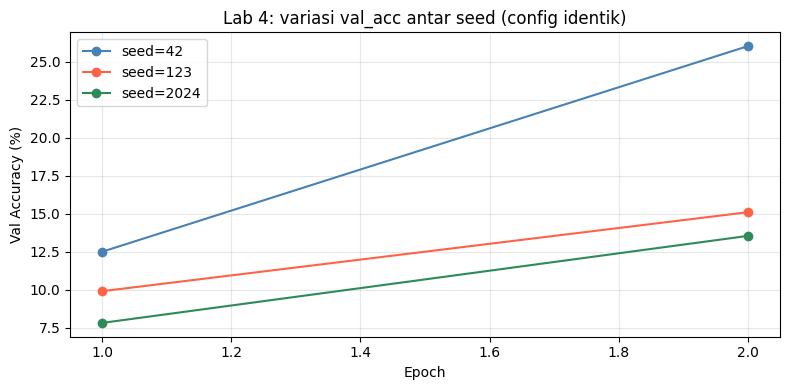

Final val_acc per seed: ['26.04%', '15.10%', '13.54%']
mean = 18.23%, std = 5.56%
Aturan 2σ: perbedaan antar konfigurasi baru bermakna jika > 11.12% (perkiraan kasar).


In [9]:
def parse_log(log_path):
    pattern = re.compile(
        r"epoch=(\d+) train_loss=([\d.]+) train_acc=([\d.]+) val_loss=([\d.]+) val_acc=([\d.]+)"
    )
    epochs, val_acc = [], []
    for line in log_path.read_text(encoding="utf-8").splitlines():
        m = pattern.search(line)
        if m:
            epochs.append(int(m.group(1)))
            val_acc.append(float(m.group(5)))
    return epochs, val_acc


seeds = [42, 123, 2024]
seed_runs = {s: run_mini(base_cfg, seed=s, suffix="_seedvar") for s in seeds}

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["steelblue", "tomato", "seagreen"]
final_accs = []
for i, s in enumerate(seeds):
    epochs, val_acc = parse_log(seed_runs[s]["out_dir"] / "train.log")
    ax.plot(epochs, [v * 100 for v in val_acc], marker="o", color=colors[i % len(colors)], label=f"seed={s}")
    final_accs.append(val_acc[-1])

ax.set_xlabel("Epoch")
ax.set_ylabel("Val Accuracy (%)")
ax.set_title("Lab 4: variasi val_acc antar seed (config identik)")
ax.legend()
ax.grid(alpha=0.3)
plot_dir = OUTPUT_DIR / "plots"
plot_dir.mkdir(exist_ok=True)
plt.tight_layout()
plt.savefig(plot_dir / "lab4_seed_variance.png", dpi=120, bbox_inches="tight")
plt.show()

mean = np.mean(final_accs) * 100
std = np.std(final_accs) * 100
print(f"Final val_acc per seed: {[f'{a*100:.2f}%' for a in final_accs]}")
print(f"mean = {mean:.2f}%, std = {std:.2f}%")
print(f"Aturan 2σ: perbedaan antar konfigurasi baru bermakna jika > {2 * std:.2f}% (perkiraan kasar).")


## 10. Refleksi

1. Jika kamu menemukan bug dua minggu kemudian dan harus memahami ulang eksperimen ini, apa **tiga minimum** yang kamu butuhkan dari folder eksperimen - bukan dari ingatanmu?

2. `cudnn.deterministic=True` memperlambat training ~10-20%. Situasi mana yang membuatmu menerima ketidakdeterminisan demi kecepatan - dan situasi mana yang tidak?

3. Bayangkan kamu menemukan folder output lama tanpa timestamp dan tanpa git history. Apa langkah yang akan kamu ambil sebelum menggunakan hasilnya di paper?


### Jawaban Refleksi

**1. Tiga minimum dari folder eksperimen:**
> *[tulis di sini]*

**2. Kapan menerima/menolak non-determinism:**
> *[tulis di sini]*

**3. Folder output tanpa timestamp dan tanpa git:**
> *[tulis di sini]*



---

# W5 Final: Full Ablation Experiment CIFAR-10

Bagian ini ditambahkan **di bawah notebook latihan W4** tanpa mengubah cell sebelumnya. Fokus bagian ini adalah memenuhi tugas jembatan W5:

1. Menjalankan matriks eksperimen: **baseline + 1 varian ablation**.
2. Setiap eksperimen dijalankan dengan **3 seed: 42, 43, 44**.
3. Hanya **1 variabel yang berubah**, yaitu `dropout` dari `0.30` menjadi `0.50`.
4. Setiap run menyimpan **config, git hash, train log, checkpoint, dan summary**.
5. Hasil dirangkum menjadi tabel **mean ± std**.
6. Notebook juga menyiapkan **1 slide PowerPoint** berisi tabel hasil dan paragraf interpretasi.

## Hipotesis Ablation

> Peningkatan dropout dari `0.30` menjadi `0.50` diperkirakan memperburuk performa model karena regularisasi yang terlalu kuat dapat menyebabkan underfitting.



## W5-1. Instalasi dan Import Library

Jalankan cell ini terlebih dahulu. Jika memakai Google Colab, library utama seperti PyTorch biasanya sudah tersedia. Jika ada library yang belum ada, aktifkan baris `%pip install` di bawah.


In [10]:

# Jika ada library yang belum tersedia, aktifkan baris ini.
# %pip install -q torch torchvision torchaudio scikit-learn pandas numpy matplotlib python-pptx

import os
import json
import random
import shutil
import subprocess
import platform
from pathlib import Path
from datetime import datetime
from copy import deepcopy

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, classification_report

print("Torch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


Torch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
CUDA available: True
Device: Tesla T4



## W5-2. Helper Reproducibility dan Git Tracking

Cell ini memastikan setiap run punya seed, config, git hash, dan folder output yang jelas.


In [11]:

def set_seed(seed: int, deterministic: bool = True):
    """Set seed agar hasil lebih mudah direproduksi."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    else:
        torch.backends.cudnn.benchmark = True


def get_git_hash():
    """Ambil git hash agar run bisa dilacak ulang. Jika bukan repo git, isi NO_GIT_REPO."""
    try:
        git_hash = subprocess.check_output(["git", "rev-parse", "HEAD"], stderr=subprocess.DEVNULL)
        return git_hash.decode("utf-8").strip()
    except Exception:
        return "NO_GIT_REPO"


def get_git_status_short():
    """Catat status perubahan file. Idealnya kosong setelah commit."""
    try:
        status = subprocess.check_output(["git", "status", "--short"], stderr=subprocess.DEVNULL)
        return status.decode("utf-8").strip()
    except Exception:
        return "NO_GIT_REPO"


def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)


def now_string():
    return datetime.now().strftime("%Y%m%d_%H%M%S")

GIT_HASH = get_git_hash()
GIT_STATUS = get_git_status_short()

print("Git hash:", GIT_HASH)
print("Git status short:", GIT_STATUS if GIT_STATUS else "clean")


Git hash: NO_GIT_REPO
Git status short: NO_GIT_REPO



## W5-3. Config Eksperimen

Baseline dan ablation dibuat hampir sama. Perbedaan utama hanya pada `dropout`:

- Baseline: `dropout = 0.30`
- Ablation: `dropout = 0.50`

Seed yang dipakai: `42, 43, 44`.


In [12]:
from copy import deepcopy
import torch

BASE_CONFIG = {
    "project": "w5_cifar10_dropout_ablation",
    "dataset": "CIFAR-10",
    "model_name": "SimpleCNN",
    "num_classes": 10,
    "image_size": 32,
    "batch_size": 128,
    "num_workers": 2,

    # Kecil dulu untuk debug
    "epochs": 10,
    "train_subset_size": 1000,
    "test_subset_size": 500,

    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "optimizer": "Adam",
    "criterion": "CrossEntropyLoss",
    "dropout": 0.30,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "deterministic": True,
}

ABLATION_CONFIG = deepcopy(BASE_CONFIG)
ABLATION_CONFIG["dropout"] = 0.50

SEEDS = [42, 43, 44]

EXPERIMENTS = [
    {
        "experiment": "baseline_dropout_0_30",
        "variant": "Baseline",
        "config": BASE_CONFIG,
    },
    {
        "experiment": "ablation_dropout_0_50",
        "variant": "Ablation",
        "config": ABLATION_CONFIG,
    },
]

changed_keys = []
for key in BASE_CONFIG:
    if BASE_CONFIG[key] != ABLATION_CONFIG[key]:
        changed_keys.append(key)

print("Changed keys between baseline and ablation:", changed_keys)
assert changed_keys == ["dropout"], "Ablation harus mengubah tepat satu variabel: dropout."

Changed keys between baseline and ablation: ['dropout']



## W5-4. Load Dataset CIFAR-10

Bagian ini mengganti mini-run/dummy dataset menjadi dataset **CIFAR-10 asli**.


In [13]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
from collections import Counter
import numpy as np
import pandas as pd

CIFAR10_CLASSES = (
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    ),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    ),
])

train_dataset_full = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset_full = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)


def make_stratified_subset(dataset, total_subset_size, num_classes=10, seed=42):
    """
    Membuat subset seimbang per kelas.
    Contoh:
    total_subset_size = 1000, num_classes = 10
    maka setiap kelas diambil 100 data.
    """
    if total_subset_size is None:
        return dataset

    assert total_subset_size % num_classes == 0, (
        "total_subset_size harus habis dibagi jumlah kelas. "
        "Contoh: 1000 untuk 10 kelas."
    )

    samples_per_class = total_subset_size // num_classes

    rng = np.random.default_rng(seed)
    targets = np.array(dataset.targets)
    selected_indices = []

    for class_id in range(num_classes):
        class_indices = np.where(targets == class_id)[0]

        if samples_per_class > len(class_indices):
            raise ValueError(
                f"Jumlah sample yang diminta untuk kelas {class_id} terlalu besar. "
                f"Tersedia {len(class_indices)}, diminta {samples_per_class}."
            )

        chosen_indices = rng.choice(
            class_indices,
            size=samples_per_class,
            replace=False
        )

        selected_indices.extend(chosen_indices.tolist())

    rng.shuffle(selected_indices)
    return Subset(dataset, selected_indices)


def get_labels_from_dataset(dataset):
    """
    Mengambil label dari dataset biasa atau Subset.
    """
    if isinstance(dataset, Subset):
        return [dataset.dataset.targets[i] for i in dataset.indices]
    return dataset.targets


def show_class_distribution(dataset, class_names, title="Class Distribution"):
    """
    Menampilkan jumlah data tiap kelas dalam bentuk tabel.
    """
    labels = get_labels_from_dataset(dataset)
    counts = Counter(labels)

    rows = []
    for class_id, class_name in enumerate(class_names):
        rows.append({
            "class_id": class_id,
            "class_name": class_name,
            "count": counts[class_id]
        })

    df = pd.DataFrame(rows)

    print(title)
    print("=" * len(title))
    display(df)

    return df


train_dataset = make_stratified_subset(
    train_dataset_full,
    total_subset_size=BASE_CONFIG["train_subset_size"],
    num_classes=BASE_CONFIG["num_classes"],
    seed=42
)

test_dataset = make_stratified_subset(
    test_dataset_full,
    total_subset_size=BASE_CONFIG["test_subset_size"],
    num_classes=BASE_CONFIG["num_classes"],
    seed=42
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BASE_CONFIG["batch_size"],
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BASE_CONFIG["batch_size"],
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))
print("Classes:", CIFAR10_CLASSES)

train_class_distribution = show_class_distribution(
    train_dataset,
    CIFAR10_CLASSES,
    title="Train Class Distribution"
)

test_class_distribution = show_class_distribution(
    test_dataset,
    CIFAR10_CLASSES,
    title="Test Class Distribution"
)

100%|██████████| 170M/170M [00:03<00:00, 44.0MB/s]


Train size: 1000
Test size: 500
Classes: ('airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
Train Class Distribution


,class_id,class_name,count
0,0,airplane,100
1,1,automobile,100
2,2,bird,100
3,3,cat,100
4,4,deer,100
5,5,dog,100
6,6,frog,100
7,7,horse,100
8,8,ship,100
9,9,truck,100


Test Class Distribution


,class_id,class_name,count
0,0,airplane,50
1,1,automobile,50
2,2,bird,50
3,3,cat,50
4,4,deer,50
5,5,dog,50
6,6,frog,50
7,7,horse,50
8,8,ship,50
9,9,truck,50



## W5-5. Model CNN untuk CIFAR-10

Model dibuat sederhana agar eksperimen tidak terlalu berat, tetapi tetap valid untuk ablation dropout.


In [14]:

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.30):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Smoke test model
model = SimpleCNN(num_classes=10, dropout=0.30)
dummy_x = torch.randn(2, 3, 32, 32)
print("Output shape:", model(dummy_x).shape)


Output shape: torch.Size([2, 10])



## W5-6. Fungsi Training, Evaluasi, dan Checkpoint

Setiap run akan menghasilkan:

- `config.json`
- `train_log.csv`
- `checkpoint_best.pt`
- `checkpoint_last.pt`
- `summary.json`


In [15]:

def make_loaders(config, seed):
    """Buat DataLoader. Generator dipakai agar shuffle lebih terkontrol oleh seed."""
    generator = torch.Generator()
    generator.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=config["batch_size"],
        shuffle=True,
        num_workers=config["num_workers"],
        pin_memory=torch.cuda.is_available(),
        generator=generator,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=config["num_workers"],
        pin_memory=torch.cuda.is_available(),
    )

    return train_loader, test_loader


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, targets in loader:
        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == targets).sum().item()
        total_samples += images.size(0)

    return {
        "train_loss": total_loss / total_samples,
        "train_accuracy": total_correct / total_samples,
    }


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_targets = []
    total_samples = 0

    for images, targets in loader:
        images = images.to(device)
        targets = targets.to(device)

        outputs = model(images)
        loss = criterion(outputs, targets)

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy().tolist())
        all_targets.extend(targets.cpu().numpy().tolist())
        total_samples += images.size(0)

    acc = accuracy_score(all_targets, all_preds)
    macro_recall = recall_score(all_targets, all_preds, average="macro", zero_division=0)

    return {
        "test_loss": total_loss / total_samples,
        "test_accuracy": acc,
        "macro_recall": macro_recall,
        "y_true": all_targets,
        "y_pred": all_preds,
    }


def save_checkpoint(path, model, optimizer, epoch, config, metrics):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "config": config,
        "metrics": metrics,
        "git_hash": GIT_HASH,
    }, path)



## W5-7. Fungsi Run Eksperimen Tunggal

Satu run = satu kombinasi `experiment` dan `seed`.


In [16]:

def run_single_experiment(experiment_name, variant, config, seed):
    set_seed(seed, deterministic=config["deterministic"])

    device = torch.device(config["device"])
    run_id = f"{experiment_name}_seed_{seed}"
    run_dir = OUTPUT_ROOT / run_id
    run_dir.mkdir(parents=True, exist_ok=True)

    # Simpan config lengkap untuk reproducibility.
    full_config = deepcopy(config)
    full_config.update({
        "experiment_name": experiment_name,
        "variant": variant,
        "seed": seed,
        "git_hash": GIT_HASH,
        "git_status_short": GIT_STATUS,
        "created_at": now_string(),
        "python_version": platform.python_version(),
        "torch_version": torch.__version__,
        "torchvision_version": torchvision.__version__,
        "classes": CIFAR10_CLASSES,
    })
    save_json(full_config, run_dir / "config.json")

    train_loader, test_loader = make_loaders(config, seed)

    model = SimpleCNN(num_classes=config["num_classes"], dropout=config["dropout"]).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"],
    )

    logs = []
    best_macro_recall = -1.0
    best_metrics = None

    for epoch in range(1, config["epochs"] + 1):
        train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
        eval_metrics = evaluate(model, test_loader, criterion, device)

        row = {
            "epoch": epoch,
            **train_metrics,
            "test_loss": eval_metrics["test_loss"],
            "test_accuracy": eval_metrics["test_accuracy"],
            "macro_recall": eval_metrics["macro_recall"],
        }
        logs.append(row)

        # Simpan checkpoint terbaik berdasarkan macro recall.
        if eval_metrics["macro_recall"] > best_macro_recall:
            best_macro_recall = eval_metrics["macro_recall"]
            best_metrics = deepcopy(row)
            save_checkpoint(
                run_dir / "checkpoint_best.pt",
                model, optimizer, epoch, full_config, best_metrics
            )

        print(
            f"[{run_id}] Epoch {epoch:02d}/{config['epochs']} | "
            f"train_loss={row['train_loss']:.4f} | "
            f"test_acc={row['test_accuracy']:.4f} | "
            f"macro_recall={row['macro_recall']:.4f}"
        )

    # Simpan log training.
    log_df = pd.DataFrame(logs)
    log_df.to_csv(run_dir / "train_log.csv", index=False)

    # Simpan checkpoint terakhir.
    save_checkpoint(
        run_dir / "checkpoint_last.pt",
        model, optimizer, config["epochs"], full_config, logs[-1]
    )

    # Evaluasi final untuk confusion matrix dan classification report.
    final_eval = evaluate(model, test_loader, criterion, device)
    cm = confusion_matrix(final_eval["y_true"], final_eval["y_pred"])
    report = classification_report(
        final_eval["y_true"],
        final_eval["y_pred"],
        target_names=CIFAR10_CLASSES,
        zero_division=0,
        output_dict=True,
    )

    np.save(run_dir / "confusion_matrix.npy", cm)
    save_json(report, run_dir / "classification_report.json")

    summary = {
        "experiment": experiment_name,
        "variant": variant,
        "seed": seed,
        "dropout": config["dropout"],
        "epochs": config["epochs"],
        "best_epoch": int(best_metrics["epoch"]),
        "best_test_accuracy": float(best_metrics["test_accuracy"]),
        "best_macro_recall": float(best_metrics["macro_recall"]),
        "final_test_accuracy": float(final_eval["test_accuracy"]),
        "final_macro_recall": float(final_eval["macro_recall"]),
        "config_path": str(run_dir / "config.json"),
        "train_log_path": str(run_dir / "train_log.csv"),
        "checkpoint_best_path": str(run_dir / "checkpoint_best.pt"),
        "checkpoint_last_path": str(run_dir / "checkpoint_last.pt"),
        "git_hash": GIT_HASH,
        "git_status_short": GIT_STATUS,
        "run_dir": str(run_dir),
    }

    save_json(summary, run_dir / "summary.json")
    return summary


In [17]:
from pathlib import Path
import json
import subprocess
import platform
from datetime import datetime

OUTPUT_ROOT = Path("outputs_w5_cifar10_ablation")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

def now_string():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")

def get_git_hash():
    try:
        return subprocess.check_output(
            ["git", "rev-parse", "--short", "HEAD"],
            stderr=subprocess.DEVNULL
        ).decode("utf-8").strip()
    except Exception:
        return "not_a_git_repo"

def get_git_status():
    try:
        return subprocess.check_output(
            ["git", "status", "--short"],
            stderr=subprocess.DEVNULL
        ).decode("utf-8").strip()
    except Exception:
        return "not_a_git_repo"

def save_json(obj, path):
    path = Path(path)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)

GIT_HASH = get_git_hash()
GIT_STATUS = get_git_status()

print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("Git hash:", GIT_HASH)
print("Git status:", GIT_STATUS)

OUTPUT_ROOT: outputs_w5_cifar10_ablation
Git hash: not_a_git_repo
Git status: not_a_git_repo



## W5-8. Jalankan Matriks Eksperimen

Cell ini menjalankan total **6 run**:

| Eksperimen | Seed |
|---|---|
| Baseline dropout 0.30 | 42, 43, 44 |
| Ablation dropout 0.50 | 42, 43, 44 |

Catatan: cell ini bisa memakan waktu cukup lama, terutama jika memakai CPU.


In [18]:

all_summaries = []

for exp in EXPERIMENTS:
    for seed in SEEDS:
        print("=" * 80)
        print(f"Running {exp['experiment']} | seed={seed}")
        print("=" * 80)

        summary = run_single_experiment(
            experiment_name=exp["experiment"],
            variant=exp["variant"],
            config=exp["config"],
            seed=seed,
        )
        all_summaries.append(summary)

raw_results_df = pd.DataFrame(all_summaries)
raw_results_path = OUTPUT_ROOT / "raw_results_all_runs.csv"
raw_results_df.to_csv(raw_results_path, index=False)

print("Saved raw results to:", raw_results_path)
raw_results_df


Running baseline_dropout_0_30 | seed=42
[baseline_dropout_0_30_seed_42] Epoch 01/10 | train_loss=2.3643 | test_acc=0.2040 | macro_recall=0.2040
[baseline_dropout_0_30_seed_42] Epoch 02/10 | train_loss=1.9810 | test_acc=0.1840 | macro_recall=0.1840
[baseline_dropout_0_30_seed_42] Epoch 03/10 | train_loss=1.8490 | test_acc=0.2040 | macro_recall=0.2040
[baseline_dropout_0_30_seed_42] Epoch 04/10 | train_loss=1.7318 | test_acc=0.3000 | macro_recall=0.3000
[baseline_dropout_0_30_seed_42] Epoch 05/10 | train_loss=1.6787 | test_acc=0.3680 | macro_recall=0.3680
[baseline_dropout_0_30_seed_42] Epoch 06/10 | train_loss=1.5813 | test_acc=0.3620 | macro_recall=0.3620
[baseline_dropout_0_30_seed_42] Epoch 07/10 | train_loss=1.5682 | test_acc=0.3900 | macro_recall=0.3900
[baseline_dropout_0_30_seed_42] Epoch 08/10 | train_loss=1.5115 | test_acc=0.3940 | macro_recall=0.3940
[baseline_dropout_0_30_seed_42] Epoch 09/10 | train_loss=1.4797 | test_acc=0.4240 | macro_recall=0.4240
[baseline_dropout_0_30_s

,experiment,variant,seed,dropout,epochs,best_epoch,best_test_accuracy,best_macro_recall,final_test_accuracy,final_macro_recall,config_path,train_log_path,checkpoint_best_path,checkpoint_last_path,git_hash,git_status_short,run_dir
0,baseline_dropout_0_30,Baseline,42,0.3,10,10,0.454,0.454,0.454,0.454,outputs_w5_cifar10_ablation/baseline_dropout_0...,outputs_w5_cifar10_ablation/baseline_dropout_0...,outputs_w5_cifar10_ablation/baseline_dropout_0...,outputs_w5_cifar10_ablation/baseline_dropout_0...,not_a_git_repo,not_a_git_repo,outputs_w5_cifar10_ablation/baseline_dropout_0...
1,baseline_dropout_0_30,Baseline,43,0.3,10,9,0.420,0.420,0.404,0.404,outputs_w5_cifar10_ablation/baseline_dropout_0...,outputs_w5_cifar10_ablation/baseline_dropout_0...,outputs_w5_cifar10_ablation/baseline_dropout_0...,outputs_w5_cifar10_ablation/baseline_dropout_0...,not_a_git_repo,not_a_git_repo,outputs_w5_cifar10_ablation/baseline_dropout_0...
2,baseline_dropout_0_30,Baseline,44,0.3,10,10,0.464,0.464,0.464,0.464,outputs_w5_cifar10_ablation/baseline_dropout_0...,outputs_w5_cifar10_ablation/baseline_dropout_0...,outputs_w5_cifar10_ablation/baseline_dropout_0...,outputs_w5_cifar10_ablation/baseline_dropout_0...,not_a_git_repo,not_a_git_repo,outputs_w5_cifar10_ablation/baseline_dropout_0...
3,ablation_dropout_0_50,Ablation,42,0.5,10,9,0.420,0.420,0.398,0.398,outputs_w5_cifar10_ablation/ablation_dropout_0...,outputs_w5_cifar10_ablation/ablation_dropout_0...,outputs_w5_cifar10_ablation/ablation_dropout_0...,outputs_w5_cifar10_ablation/ablation_dropout_0...,not_a_git_repo,not_a_git_repo,outputs_w5_cifar10_ablation/ablation_dropout_0...
4,ablation_dropout_0_50,Ablation,43,0.5,10,10,0.446,0.446,0.446,0.446,outputs_w5_cifar10_ablation/ablation_dropout_0...,outputs_w5_cifar10_ablation/ablation_dropout_0...,outputs_w5_cifar10_ablation/ablation_dropout_0...,outputs_w5_cifar10_ablation/ablation_dropout_0...,not_a_git_repo,not_a_git_repo,outputs_w5_cifar10_ablation/ablation_dropout_0...
5,ablation_dropout_0_50,Ablation,44,0.5,10,10,0.442,0.442,0.442,0.442,outputs_w5_cifar10_ablation/ablation_dropout_0...,outputs_w5_cifar10_ablation/ablation_dropout_0...,outputs_w5_cifar10_ablation/ablation_dropout_0...,outputs_w5_cifar10_ablation/ablation_dropout_0...,not_a_git_repo,not_a_git_repo,outputs_w5_cifar10_ablation/ablation_dropout_0...



## W5-9. Tabel Tracking Tiap Run

Tabel ini penting untuk menunjukkan bahwa setiap run terlacak: config, git hash, log, dan checkpoint.


In [19]:

tracking_columns = [
    "variant", "experiment", "seed", "dropout", "epochs",
    "best_epoch", "best_test_accuracy", "best_macro_recall",
    "config_path", "train_log_path", "checkpoint_best_path", "git_hash"
]

tracking_df = raw_results_df[tracking_columns].copy()
tracking_df.to_csv(OUTPUT_ROOT / "tracking_table.csv", index=False)
tracking_df


,variant,experiment,seed,dropout,epochs,best_epoch,best_test_accuracy,best_macro_recall,config_path,train_log_path,checkpoint_best_path,git_hash
0,Baseline,baseline_dropout_0_30,42,0.3,10,10,0.454,0.454,outputs_w5_cifar10_ablation/baseline_dropout_0...,outputs_w5_cifar10_ablation/baseline_dropout_0...,outputs_w5_cifar10_ablation/baseline_dropout_0...,not_a_git_repo
1,Baseline,baseline_dropout_0_30,43,0.3,10,9,0.420,0.420,outputs_w5_cifar10_ablation/baseline_dropout_0...,outputs_w5_cifar10_ablation/baseline_dropout_0...,outputs_w5_cifar10_ablation/baseline_dropout_0...,not_a_git_repo
2,Baseline,baseline_dropout_0_30,44,0.3,10,10,0.464,0.464,outputs_w5_cifar10_ablation/baseline_dropout_0...,outputs_w5_cifar10_ablation/baseline_dropout_0...,outputs_w5_cifar10_ablation/baseline_dropout_0...,not_a_git_repo
3,Ablation,ablation_dropout_0_50,42,0.5,10,9,0.420,0.420,outputs_w5_cifar10_ablation/ablation_dropout_0...,outputs_w5_cifar10_ablation/ablation_dropout_0...,outputs_w5_cifar10_ablation/ablation_dropout_0...,not_a_git_repo
4,Ablation,ablation_dropout_0_50,43,0.5,10,10,0.446,0.446,outputs_w5_cifar10_ablation/ablation_dropout_0...,outputs_w5_cifar10_ablation/ablation_dropout_0...,outputs_w5_cifar10_ablation/ablation_dropout_0...,not_a_git_repo
5,Ablation,ablation_dropout_0_50,44,0.5,10,10,0.442,0.442,outputs_w5_cifar10_ablation/ablation_dropout_0...,outputs_w5_cifar10_ablation/ablation_dropout_0...,outputs_w5_cifar10_ablation/ablation_dropout_0...,not_a_git_repo



## W5-10. Rekap Mean ± Std

Hasil akhir tugas dirangkum dalam format **mean ± std** dari 3 seed.


In [20]:

def mean_std_text(series, scale=100, digits=2):
    mean = series.mean() * scale
    std = series.std(ddof=1) * scale
    return f"{mean:.{digits}f} ± {std:.{digits}f}"

summary_rows = []
for variant, group in raw_results_df.groupby("variant", sort=False):
    summary_rows.append({
        "Variant": variant,
        "Dropout": group["dropout"].iloc[0],
        "Seeds": ", ".join(map(str, sorted(group["seed"].tolist()))),
        "Best Test Accuracy (%)": mean_std_text(group["best_test_accuracy"]),
        "Best Macro Recall (%)": mean_std_text(group["best_macro_recall"]),
        "Final Test Accuracy (%)": mean_std_text(group["final_test_accuracy"]),
        "Final Macro Recall (%)": mean_std_text(group["final_macro_recall"]),
    })

summary_table = pd.DataFrame(summary_rows)
summary_table.to_csv(OUTPUT_ROOT / "summary_mean_std.csv", index=False)
summary_table


,Variant,Dropout,Seeds,Best Test Accuracy (%),Best Macro Recall (%),Final Test Accuracy (%),Final Macro Recall (%)
0,Baseline,0.3,"42, 43, 44",44.60 ± 2.31,44.60 ± 2.31,44.07 ± 3.21,44.07 ± 3.21
1,Ablation,0.5,"42, 43, 44",43.60 ± 1.40,43.60 ± 1.40,42.87 ± 2.66,42.87 ± 2.66



## W5-11. Analisis Selisih Baseline vs Ablation

Cell ini otomatis menentukan apakah hipotesis didukung atau tidak.


In [21]:

# Ambil mean metric utama.
metric_main = "best_macro_recall"
mean_by_variant = raw_results_df.groupby("variant")[["best_test_accuracy", "best_macro_recall"]].mean()

baseline_acc = mean_by_variant.loc["Baseline", "best_test_accuracy"]
ablation_acc = mean_by_variant.loc["Ablation", "best_test_accuracy"]
baseline_recall = mean_by_variant.loc["Baseline", "best_macro_recall"]
ablation_recall = mean_by_variant.loc["Ablation", "best_macro_recall"]

acc_delta = (ablation_acc - baseline_acc) * 100
recall_delta = (ablation_recall - baseline_recall) * 100

hypothesis = "Peningkatan dropout dari 0.30 menjadi 0.50 diperkirakan memperburuk performa model."

if recall_delta < 0:
    conclusion = (
        "Hipotesis didukung. Varian ablation dengan dropout 0.50 menghasilkan macro recall "
        "lebih rendah dibanding baseline dropout 0.30. Hal ini menunjukkan bahwa regularisasi "
        "yang lebih kuat cenderung mengurangi kemampuan model dalam mempelajari pola CIFAR-10, "
        "sehingga model berpotensi mengalami underfitting."
    )
elif recall_delta > 0:
    conclusion = (
        "Hipotesis tidak didukung. Varian ablation dengan dropout 0.50 justru menghasilkan macro recall "
        "lebih tinggi dibanding baseline dropout 0.30. Artinya, pada konfigurasi eksperimen ini, "
        "regularisasi yang lebih kuat membantu generalisasi model dan baseline kemungkinan masih memiliki "
        "kecenderungan overfitting."
    )
else:
    conclusion = (
        "Hipotesis tidak menunjukkan perbedaan kuat. Macro recall baseline dan ablation relatif sama, "
        "sehingga peningkatan dropout dari 0.30 menjadi 0.50 belum memberikan dampak yang jelas pada konfigurasi ini."
    )

interpretation = (
    f"Hipotesis: {hypothesis} "
    f"Berdasarkan tiga seed (42, 43, 44), perubahan dropout dari 0.30 ke 0.50 menghasilkan "
    f"selisih test accuracy sebesar {acc_delta:+.2f} poin persentase dan selisih macro recall "
    f"sebesar {recall_delta:+.2f} poin persentase. {conclusion}"
)

print(interpretation)

analysis_summary = {
    "hypothesis": hypothesis,
    "baseline_mean_accuracy": baseline_acc,
    "ablation_mean_accuracy": ablation_acc,
    "accuracy_delta_percentage_point": acc_delta,
    "baseline_mean_macro_recall": baseline_recall,
    "ablation_mean_macro_recall": ablation_recall,
    "macro_recall_delta_percentage_point": recall_delta,
    "interpretation": interpretation,
}

save_json(analysis_summary, OUTPUT_ROOT / "analysis_summary.json")


Hipotesis: Peningkatan dropout dari 0.30 menjadi 0.50 diperkirakan memperburuk performa model. Berdasarkan tiga seed (42, 43, 44), perubahan dropout dari 0.30 ke 0.50 menghasilkan selisih test accuracy sebesar -1.00 poin persentase dan selisih macro recall sebesar -1.00 poin persentase. Hipotesis didukung. Varian ablation dengan dropout 0.50 menghasilkan macro recall lebih rendah dibanding baseline dropout 0.30. Hal ini menunjukkan bahwa regularisasi yang lebih kuat cenderung mengurangi kemampuan model dalam mempelajari pola CIFAR-10, sehingga model berpotensi mengalami underfitting.



## W5-13. File yang Harus Dipush ke GitHub

Setelah semua cell selesai dijalankan, push file berikut ke GitHub:

```text
lab_w4_experiment_tracking_W5_ablation_full.ipynb
outputs_w5_cifar10_ablation/
├── raw_results_all_runs.csv
├── tracking_table.csv
├── summary_mean_std.csv
├── analysis_summary.json
├── w5_ablation_slide.pptx
├── baseline_dropout_0_30_seed_42/
│   ├── config.json
│   ├── train_log.csv
│   ├── checkpoint_best.pt
│   ├── checkpoint_last.pt
│   └── summary.json
├── baseline_dropout_0_30_seed_43/
├── baseline_dropout_0_30_seed_44/
├── ablation_dropout_0_50_seed_42/
├── ablation_dropout_0_50_seed_43/
└── ablation_dropout_0_50_seed_44/
```

Minimal yang wajib terlihat oleh dosen/asisten:

- Notebook eksperimen.
- Tabel hasil `summary_mean_std.csv`.
- Tabel tracking `tracking_table.csv`.
- Log training tiap run.
- Checkpoint tiap run.
- Config tiap run.
- Git hash.
- Slide presentasi W5.
